# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1

## Deploy TensorBoard

In [78]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [79]:
import os
import sys
import json
import ipynbname
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)

## Parameters

In [80]:
RANDOM_SEED = 18

In [81]:
MAX_TIMESHIFT = 10
MIN_TIMESHIFT = 10

In [82]:
FORECAST_HORIZON = 1

In [83]:
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"

In [84]:
# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

In [85]:
INPUT_SIZE = None
OUTPUT_SIZE = 1

## Hyper Parameters

In [86]:
MAX_EPOCHS = 1000
LEARNING_RATE = 0.00001
PATIENCE = 35
BATCH_SIZE = 128

## Start

### Get data

In [87]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [88]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [89]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [90]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [91]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [92]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


In [93]:
vn_index_df_close = vn_index_df[["date", "close"]]
vn_index_df_close

,date,close
0,2008-03-07,640.140
1,2008-03-08,646.190
2,2008-03-09,652.240
3,2008-03-10,658.290
4,2008-03-11,638.710
...,...,...
6561,2026-02-22,1856.535
6562,2026-02-23,1860.140
6563,2026-02-24,1867.620
6564,2026-02-25,1860.910


In [94]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41112\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2008-03-07,640.140,vn_index
1,2008-03-08,646.190,vn_index
2,2008-03-09,652.240,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
...,...,...,...
6561,2026-02-22,1856.535,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


In [95]:
input_df = vn_index_df_close

### Roll time series

In [96]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:14<00:00,  3.45it/s]


,date,close,stock,id
0,2008-03-07,640.140,vn_index,"(vn_index, 2008-03-17)"
1,2008-03-08,646.190,vn_index,"(vn_index, 2008-03-17)"
2,2008-03-09,652.240,vn_index,"(vn_index, 2008-03-17)"
3,2008-03-10,658.290,vn_index,"(vn_index, 2008-03-17)"
4,2008-03-11,638.710,vn_index,"(vn_index, 2008-03-17)"
...,...,...,...,...
72111,2026-02-22,1856.535,vn_index,"(vn_index, 2026-02-26)"
72112,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
72113,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
72114,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [97]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [01:09<00:00,  1.38s/it]


In [98]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-03-17                                             1.0   
         2008-03-18                                             1.0   
         2008-03-19                                             1.0   
         2008-03-20                                             1.0   
         2008-03-21                                             1.0   
...                                                             ...   
         2026-02-22                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-03-17                       0.0                       0.0   
         2008-03-18                       0.0                       0.0   
         2008-03-19                       0.0                       0.0   
         2008-03-20                       0.0                       0.0   
         2008-03-21                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-22                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-03-17                   0.0           7046.090   
         2008-03-18                   0.0           6994.210   
         2008-03-19                   0.0           6921.470   
         2008-03-20                   0.0           6834.050   
         2008-03-21                   0.0           6721.440   
...                                   ...                ...   
         2026-02-22                   0.0          20217.215   
         2026-02-23                   0.0          20263.265   
         2026-02-24                   0.0          20306.795   
         2026-02-25                   0.0          20340.010   
         2026-02-26                   0.0          20388.350   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-03-17       4.514851e+06                  7.8510   
         2008-03-18       4.451121e+06                  9.9910   
         2008-03-19       4.362405e+06                 10.8670   
         2008-03-20       4.256009e+06                 11.1250   
         2008-03-21       4.120430e+06                 11.0810   
...                                ...                     ...   
         2026-02-22       3.715950e+07                  4.2445   
         2026-02-23       3.732869e+07                  3.6050   
         2026-02-24       3.748939e+07                  3.9925   
         2026-02-25       3.761191e+07                  4.3030   
         2026-02-26       3.779130e+07                  5.8155   

                     close__mean_change  \
vn_index 2008-03-17             -2.4430   
         2008-03-18             -5.7930   
         2008-03-19             -7.8790   
         2008-03-20             -9.3470   
         2008-03-21             -9.3030   
...                                 ...   
         2026-02-22              4.2445   
         2026-02-23              3.6050   
         2026-02-24              3.9925   
         2026-02-25              2.9610   
         2026-02-26              4.4735   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-03-17                              -0.856296     643.800000   
         2008-03-18               

In [99]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-17,1.0,0.0,0.0,0.0,7046.090,4.514851e+06,7.8510,-2.4430,-0.856296,643.800000,...,0.867563,1.329661,1.791759,1.310784,1.906155,1.945910,1.791759,1.609438,0.0,647.451429
2008-03-18,1.0,0.0,0.0,0.0,6994.210,4.451121e+06,9.9910,-5.7930,-1.861111,643.800000,...,0.867563,1.242453,1.560710,1.273028,1.667462,1.747868,1.791759,1.609438,0.0,647.247143
2008-03-19,1.0,0.0,0.0,0.0,6921.470,4.362405e+06,10.8670,-7.8790,-1.158889,638.710000,...,0.450561,0.867563,1.560710,1.149060,1.386294,1.475076,1.560710,1.609438,0.0,645.568095
2008-03-20,1.0,0.0,0.0,0.0,6834.050,4.256009e+06,11.1250,-9.3470,0.608333,634.436667,...,0.450561,0.450561,1.560710,1.002718,1.073543,1.153742,1.242453,1.332179,0.0,641.687143
2008-03-21,1.0,0.0,0.0,0.0,6721.440,4.120430e+06,11.0810,-9.3030,-1.351667,625.073333,...,0.450561,0.867563,1.242453,0.683739,0.735622,0.796312,0.867563,0.950271,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-22,1.0,0.0,0.0,0.0,20217.215,3.715950e+07,4.2445,4.2445,-0.355278,1838.510000,...,0.450561,0.867563,1.242453,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1845.720000
2026-02-23,1.0,0.0,0.0,0.0,20263.265,3.732869e+07,3.6050,3.6050,0.000000,1842.115000,...,0.450561,0.450561,1.242453,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1849.325000
2026-02-24,1.0,0.0,0.0,0.0,20306.795,3.748939e+07,3.9925,3.9925,0.215278,1845.720000,...,0.450561,0.450561,1.011404,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1853.483571


### Create forecast target

In [100]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,646.190
2008-03-08,652.240
2008-03-09,658.290
2008-03-10,638.710
2008-03-11,643.900
...,...
2026-02-21,1856.535
2026-02-22,1860.140
2026-02-23,1867.620


In [101]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [102]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-17,1.0,0.0,0.0,0.0,7046.090,4.514851e+06,7.8510,-2.4430,-0.856296,643.800000,...,0.867563,1.329661,1.791759,1.310784,1.906155,1.945910,1.791759,1.609438,0.0,647.451429
2008-03-18,1.0,0.0,0.0,0.0,6994.210,4.451121e+06,9.9910,-5.7930,-1.861111,643.800000,...,0.867563,1.242453,1.560710,1.273028,1.667462,1.747868,1.791759,1.609438,0.0,647.247143
2008-03-19,1.0,0.0,0.0,0.0,6921.470,4.362405e+06,10.8670,-7.8790,-1.158889,638.710000,...,0.450561,0.867563,1.560710,1.149060,1.386294,1.475076,1.560710,1.609438,0.0,645.568095
2008-03-20,1.0,0.0,0.0,0.0,6834.050,4.256009e+06,11.1250,-9.3470,0.608333,634.436667,...,0.450561,0.450561,1.560710,1.002718,1.073543,1.153742,1.242453,1.332179,0.0,641.687143
2008-03-21,1.0,0.0,0.0,0.0,6721.440,4.120430e+06,11.0810,-9.3030,-1.351667,625.073333,...,0.450561,0.867563,1.242453,0.683739,0.735622,0.796312,0.867563,0.950271,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,1.0,0.0,0.0,0.0,20157.530,3.694144e+07,5.6080,5.6080,-0.757500,1834.905000,...,0.867563,0.867563,1.242453,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1842.115000
2026-02-22,1.0,0.0,0.0,0.0,20217.215,3.715950e+07,4.2445,4.2445,-0.355278,1838.510000,...,0.450561,0.867563,1.242453,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1845.720000
2026-02-23,1.0,0.0,0.0,0.0,20263.265,3.732869e+07,3.6050,3.6050,0.000000,1842.115000,...,0.450561,0.450561,1.242453,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1849.325000


In [103]:
y

,close
date,
2008-03-17,588.260000
2008-03-18,573.450000
2008-03-19,564.820000
2008-03-20,545.680000
2008-03-21,537.476667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create train set

In [104]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [105]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-17,1.0,0.0,0.0,0.0,7046.09,4.514851e+06,7.851,-2.443,-0.856296,643.800000,...,0.867563,1.329661,1.791759,1.310784,1.906155,1.945910,1.791759,1.609438,0.0,647.451429
2008-03-18,1.0,0.0,0.0,0.0,6994.21,4.451121e+06,9.991,-5.793,-1.861111,643.800000,...,0.867563,1.242453,1.560710,1.273028,1.667462,1.747868,1.791759,1.609438,0.0,647.247143
2008-03-19,1.0,0.0,0.0,0.0,6921.47,4.362405e+06,10.867,-7.879,-1.158889,638.710000,...,0.450561,0.867563,1.560710,1.149060,1.386294,1.475076,1.560710,1.609438,0.0,645.568095
2008-03-20,1.0,0.0,0.0,0.0,6834.05,4.256009e+06,11.125,-9.347,0.608333,634.436667,...,0.450561,0.450561,1.560710,1.002718,1.073543,1.153742,1.242453,1.332179,0.0,641.687143
2008-03-21,1.0,0.0,0.0,0.0,6721.44,4.120430e+06,11.081,-9.303,-1.351667,625.073333,...,0.450561,0.867563,1.242453,0.683739,0.735622,0.796312,0.867563,0.950271,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,16259.43,2.403418e+07,5.757,0.909,0.265000,1478.740000,...,1.329661,1.560710,1.791759,1.464816,1.906155,1.945910,1.791759,1.609438,0.0,1481.491429
2021-12-28,1.0,0.0,0.0,0.0,16274.03,2.407760e+07,6.226,1.542,0.351667,1478.740000,...,1.242453,1.560710,1.791759,1.427061,1.667462,1.747868,1.791759,1.609438,0.0,1483.577143
2021-12-29,1.0,0.0,0.0,0.0,16280.88,2.409791e+07,7.001,0.767,-0.430556,1478.740000,...,1.329661,1.560710,1.560710,1.581094,1.667462,1.747868,1.791759,1.609438,0.0,1484.555714


In [106]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-03-17,588.260000
2008-03-18,573.450000
2008-03-19,564.820000
2008-03-20,545.680000
2008-03-21,537.476667
...,...
2021-12-27,1494.390000
2021-12-28,1485.820000
2021-12-29,1485.970000


### Select features

In [107]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,close__abs_energy,close__maximum,close__absolute_maximum,close__benford_correlation,close__minimum,close__mean_n_absolute_max__number_of_maxima_7,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",close__c3__lag_1,...,close__longest_strike_below_mean,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__number_cwt_peaks__n_5,close__index_mass_quantile__q_0.2,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__permutation_entropy__dimension_7__tau_1,close__autocorrelation__lag_4,close__cid_ce__normalize_True,close__autocorrelation__lag_5
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-17,7046.09,4.514851e+06,658.29,658.29,-0.200946,615.71,647.451429,643.038,625.073333,2.656678e+08,...,3.0,0.558899,0.558899,1.0,0.272727,0.090357,1.609438,-0.060637,2.478984,-0.109609
2008-03-18,6994.21,4.451121e+06,658.29,658.29,-0.217108,588.26,647.247143,640.595,615.710000,2.608455e+08,...,4.0,0.555995,0.555995,2.0,0.272727,0.093147,1.609438,-0.100144,2.065039,-0.247381
2008-03-19,6921.47,4.362405e+06,658.29,658.29,-0.233953,573.45,645.568095,634.802,588.260000,2.530957e+08,...,4.0,0.693801,0.693801,2.0,0.272727,0.096136,1.609438,-0.065286,1.611620,-0.333081
2008-03-20,6834.05,4.256009e+06,658.29,658.29,-0.249642,564.82,641.687143,626.923,573.450000,2.437954e+08,...,4.0,0.758939,0.758939,1.0,0.272727,0.097387,1.332179,-0.090393,1.375359,-0.407785
2008-03-21,6721.44,4.120430e+06,647.60,647.60,-0.261003,545.68,635.604286,617.576,564.820000,2.333522e+08,...,4.0,0.821356,0.821356,1.0,0.272727,0.097686,0.950271,-0.152932,1.194012,-0.483134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,16259.43,2.403418e+07,1488.88,1488.88,0.864123,1456.96,1481.491429,1477.055,1456.960000,3.221659e+09,...,3.0,0.216825,0.216825,3.0,0.272727,0.090982,1.609438,-0.573894,3.946863,-0.063596
2021-12-28,16274.03,2.407760e+07,1494.39,1494.39,0.864123,1456.96,1483.577143,1477.964,1456.960000,3.229314e+09,...,7.0,0.378357,0.378357,2.0,0.272727,0.090686,1.609438,-0.405737,3.405620,-0.731891
2021-12-29,16280.88,2.409791e+07,1494.39,1494.39,0.864123,1456.96,1484.555714,1479.506,1456.960000,3.237787e+09,...,6.0,0.476497,0.476497,3.0,0.272727,0.088088,1.609438,-0.351517,3.467412,-0.757230


In [108]:
INPUT_SIZE = X_train_selected.shape[1]
INPUT_SIZE

222

### Create validation set

In [109]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [110]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,close__abs_energy,close__maximum,close__absolute_maximum,close__benford_correlation,close__minimum,close__mean_n_absolute_max__number_of_maxima_7,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",close__c3__lag_1,...,close__longest_strike_below_mean,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__number_cwt_peaks__n_5,close__index_mass_quantile__q_0.2,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__permutation_entropy__dimension_7__tau_1,close__autocorrelation__lag_4,close__cid_ce__normalize_True,close__autocorrelation__lag_5
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,16336.015000,2.426209e+07,1505.1050,1505.1050,0.864123,1456.96,1491.910714,1483.091000,1456.96,3.273075e+09,...,5.0,0.539347,0.539347,1.0,0.272727,0.090883,1.609438,0.051477,2.844385,-0.257578
2022-01-02,16370.275000,2.436452e+07,1511.9300,1511.9300,0.864123,1456.96,1495.767857,1485.834500,1456.96,3.298586e+09,...,4.0,0.505803,0.505803,1.0,0.272727,0.090983,1.609438,-0.007933,2.014478,-0.021448
2022-01-03,16432.070000,2.454840e+07,1518.7550,1518.7550,0.864123,1477.03,1500.472857,1491.331500,1477.03,3.328483e+09,...,4.0,0.682644,0.682644,1.0,0.272727,0.090971,1.609438,-0.171236,1.655753,-0.051082
2022-01-04,16480.620000,2.469418e+07,1525.5800,1525.5800,0.864123,1480.98,1506.131429,1495.504000,1480.98,3.356805e+09,...,6.0,0.734573,0.734573,2.0,0.272727,0.089400,1.609438,-0.048013,1.508744,-0.397921
2022-01-05,16522.140000,2.481888e+07,1525.5800,1525.5800,0.864123,1484.93,1510.934286,1499.964000,1484.93,3.384953e+09,...,6.0,0.832118,0.832118,2.0,0.272727,0.088969,1.609438,-0.100222,1.456829,-0.589650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,12172.403333,1.347092e+07,1122.2500,1122.2500,0.864123,1091.88,1112.587143,1105.041333,1091.88,1.354004e+09,...,6.0,0.857497,0.857497,1.0,0.272727,0.090220,0.950271,-0.043505,1.181405,-0.360971
2023-12-28,12205.980000,1.354561e+07,1128.9300,1128.9300,0.864123,1091.88,1116.372857,1107.705000,1091.88,1.366262e+09,...,6.0,0.764803,0.764803,1.0,0.272727,0.089826,0.950271,0.011615,1.187040,-0.369780
2023-12-29,12244.030000,1.363015e+07,1129.9300,1129.9300,0.864123,1096.30,1120.211429,1111.410000,1096.30,1.378883e+09,...,6.0,0.811890,0.811890,1.0,0.272727,0.090058,1.332179,-0.026989,1.139325,-0.427690


In [111]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1511.9300
2022-01-02,1518.7550
2022-01-03,1525.5800
2022-01-04,1522.5000
2022-01-05,1528.5700
...,...
2023-12-27,1128.9300
2023-12-28,1129.9300
2023-12-29,1130.3775


### Create test set

In [112]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [113]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,close__abs_energy,close__maximum,close__absolute_maximum,close__benford_correlation,close__minimum,close__mean_n_absolute_max__number_of_maxima_7,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",close__c3__lag_1,...,close__longest_strike_below_mean,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__number_cwt_peaks__n_5,close__index_mass_quantile__q_0.2,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__permutation_entropy__dimension_7__tau_1,close__autocorrelation__lag_4,close__cid_ce__normalize_True,close__autocorrelation__lag_5
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,12337.015000,1.383754e+07,1131.2725,1131.2725,0.864123,1103.060000,1127.939286,1120.574250,1103.060000,1.414004e+09,...,4.0,0.782927,0.782927,2.0,0.272727,0.091017,1.609438,-0.053450,1.247640,-0.375799
2024-01-02,12365.675000,1.390159e+07,1131.7200,1131.7200,0.864123,1107.926667,1129.329286,1123.395500,1107.926667,1.423761e+09,...,5.0,0.750163,0.750163,1.0,0.272727,0.090555,1.609438,-0.011894,1.374084,-0.466170
2024-01-03,12401.918333,1.398322e+07,1144.1700,1144.1700,0.864123,1112.793333,1132.460714,1125.774833,1112.793333,1.433418e+09,...,4.0,0.522076,0.522076,1.0,0.272727,0.091144,1.332179,-0.031967,1.969691,-0.144026
2024-01-04,12439.845000,1.406906e+07,1150.7200,1150.7200,0.864123,1117.660000,1135.573571,1128.912500,1117.660000,1.443893e+09,...,7.0,0.590835,0.590835,1.0,0.272727,0.090748,0.950271,0.014029,1.808880,-0.041758
2024-01-05,12476.865000,1.415318e+07,1154.6800,1154.6800,0.864123,1121.990000,1139.109286,1132.218500,1121.990000,1.456445e+09,...,8.0,0.712365,0.712365,1.0,0.272727,0.090280,0.500402,-0.054136,1.574102,-0.133951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,20157.530000,3.694144e+07,1852.9300,1852.9300,0.864123,1796.850000,1842.115000,1830.460000,1796.850000,6.166263e+09,...,5.0,0.656389,0.656389,1.0,0.272727,0.090783,-0.000000,0.028436,1.425067,-0.210590
2026-02-22,20217.215000,3.715950e+07,1856.5350,1856.5350,0.864123,1814.090000,1845.720000,1836.068000,1814.090000,6.212468e+09,...,5.0,0.733359,0.733359,1.0,0.272727,0.090606,-0.000000,0.020093,1.185806,-0.282581
2026-02-23,20263.265000,3.732869e+07,1860.1400,1860.1400,0.864123,1824.090000,1849.325000,1840.312500,1824.090000,6.251465e+09,...,5.0,0.800000,0.800000,1.0,0.272727,0.090550,-0.000000,0.000000,1.000000,-0.333333


In [114]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create scaler

In [115]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaler = X_scaler.fit_transform(X_train_selected)
y_train_scaler = y_scaler.fit_transform(y_train)

X_validation_scaler = X_scaler.transform(X_validation_selected)
y_validation_scaler = y_scaler.transform(y_validation)

X_test_scaler = X_scaler.transform(X_test_selected)
y_test_scaler = y_scaler.transform(y_test)

In [116]:
X_train_scaler.shape

(5038, 222)

In [117]:
y_train_scaler.shape

(5038, 1)

In [118]:
X_validation_scaler.shape

(730, 222)

In [119]:
y_validation_scaler.shape

(730, 1)

In [120]:
X_test_scaler.shape

(787, 222)

In [121]:
y_test_scaler.shape

(787, 1)

### Create dataloader

In [122]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaler, dtype=torch.float32),
    torch.tensor(y_train_scaler, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [123]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaler, dtype=torch.float32),
    torch.tensor(y_validation_scaler, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [124]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaler, dtype=torch.float32),
    torch.tensor(y_test_scaler, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [125]:
config_dto = ConfigDto(
    # Data
    base_features=["close"],
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    lookback_window_size=MAX_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params={"test": 10},
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [126]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [127]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

Seed set to 18


### Train model

In [128]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [129]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │  6.3 K │ train │     0 │
│ 1 │ fc   │ Sequential │  225 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 231 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 231 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

In [130]:
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


In [131]:
y_test.shape

(787, 1)

In [132]:
y_pred_tensor = model(torch.tensor(X_test_scaler, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1129.159180
2024-01-02,1131.005859
2024-01-03,1143.702148
2024-01-04,1150.344727
2024-01-05,1153.647095
...,...
2026-02-21,1869.436401
2026-02-22,1867.993042
2026-02-23,1852.135010


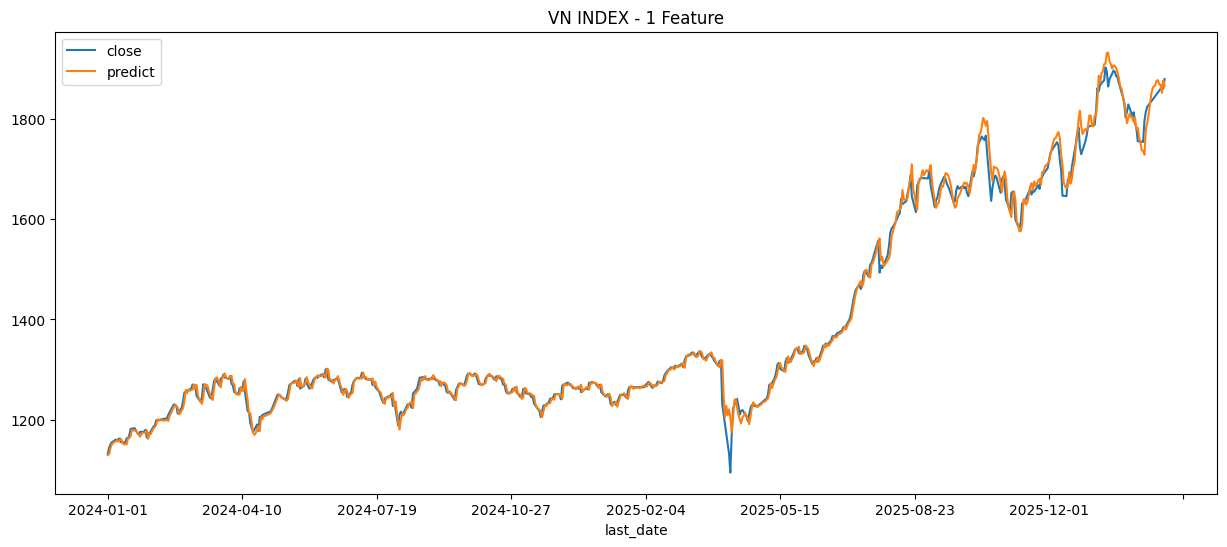

In [133]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [134]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [135]:
# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
# denominator = mean squared difference of actuals
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")

MSE: 234.6318
MAPE: 0.6485 %
RMSSE: 1.3393


### Predict

In [136]:
# Get last row and keep 2D shape
last_row = X_test_scaler[-1:]
last_row.shape

(1, 222)

In [137]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

np.float32(1865.4641)

### Save data

In [138]:
import os
import sys
import pickle
import ipynbname
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

Saved results to: lightning_logs\version_0
